# Seasonal Agriculture Performance Analysis

## Major Project – VOIS AICTE Batch 1 2026–2027

## 1. Introduction

Seasons play a crucial role in agriculture. Rainfall, temperature, soil conditions, and even the level of pest infestation can differ in the Kharif, Rabi, and Zaid season, and this has an impact on the quantity of produce farmers are able to produce and the profit they earn.

This project studies the dataset containing 4000 records of farms that have been recorded over different states, crops, and seasons of the year. These records contain information about the farming situation of the farm, the resources used for farming, and the monetary outcome of the farm.

The objective is to determine the nature of farming changes with seasons and crops and analyze whether these changes are random or something that farmers can rely upon.

The project involves standard steps of data analysis: exploration, cleaning, understanding the data in different ways, applying statistical methods, and determining the conclusions from the data.


## 2. Objectives

This project aims to:

1. Explore and understand the dataset before doing any analysis.
2. Clean the data so the results can be trusted.
3. Compare agricultural performance across Kharif, Rabi, and Zaid.
4. Compare crops with each other across seasons.
5. Look at how yield, revenue, cost, profit, and profit margin change by season and crop.
6. Study water usage and water efficiency across seasons and irrigation methods.
7. Check how environmental and resource factors relate to yield.
8. Compare performance across different states.
9. Use statistical tests to check if the differences observed are actually significant.
10. Summarize the findings and turn them into practical recommendations.


## 3. Analytical Questions

Based on the objectives above, the following questions guided the analysis:

1. How does yield change across Kharif, Rabi, and Zaid?
2. Which crops give the highest and lowest yield in each season?
3. How do revenue, cost, profit, and profit margin differ across seasons?
4. Which crop-season combinations perform the best and worst financially?
5. How does water usage and water efficiency vary across seasons?
6. Does the irrigation method used affect yield, water efficiency, or profit?
7. Are there noticeable differences in performance across states?
8. How do environmental conditions relate to yield?
9. How does resource usage (fertilizer, nitrogen, etc.) relate to yield?
10. Is there a relationship between disease/pest risk and profit?
11. Are the seasonal differences in yield, profit, and water efficiency statistically significant, or could they be due to chance?
12. Do crops differ significantly from each other in yield?
13. Are there any unexpected or unusual patterns in the data?
14. What recommendations can be made for better seasonal planning based on the findings?


## 4. Dataset Description

The dataset used is **`seasonal_agriculture_performance_dataset.csv`**, containing **4,000 rows and 28 columns**. Each row represents one farm record for a particular crop and season.

The columns can be grouped roughly like this:

- **Location:** Farm ID, State, District
- **Crop and Season:** Crop, Season
- **Environmental conditions:** Rainfall, temperature, humidity, sunlight hours, soil pH, soil moisture
- **Resource usage:** Nitrogen, phosphorus, potassium, fertilizer, pesticide, water used
- **Farming practices:** Irrigation method, seed quality score
- **Output:** Yield, production
- **Financials:** Market price, total cost, revenue, profit
- **Efficiency:** Water-use efficiency
- **Risk:** Disease/pest risk percentage

The three seasons in the dataset are **Kharif, Rabi, and Zaid**.


In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def format_p(p, threshold=0.001):
    """Show very small p-values as '< 0.001' instead of rounding them to 0."""
    return f"< {threshold}" if p < threshold else f"{p:.4f}"

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Load the agricultural dataset

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 4000
Columns: 28


In [3]:
# Display the first five records

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
# Check the dataset structure

print("Dataset Information")
print("=" * 50)

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset Information
Number of rows: 4000
Number of columns: 28

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:
Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day             

In [5]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing Values by Column")
print("=" * 50)
print(missing_values[missing_values > 0])

Missing Values by Column
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


## 5. Data Quality Assessment and Cleaning

### Missing Values

Before doing any analysis, the dataset was checked for missing values. Three columns had missing data:

- `Rainfall_mm`: 48 missing values
- `Soil_Moisture_pct`: 40 missing values
- `Yield_Tonnes_Ha`: 32 missing values

That's 120 missing cells in total, which is a very small fraction of the 4,000 x 28 = 112,000 cells in the dataset. Since the amount of missing data was small, it made more sense to fill in these values than to drop the rows and lose good data.

### How the missing values were filled

- **Rainfall:** filled with the median rainfall for that season.
- **Soil Moisture:** filled with the median soil moisture for that season.
- **Yield:** filled with the median yield for that specific Crop + Season combination.

The median was used instead of the mean because it isn't affected as much by unusually high or low values. Filling values within the same season/crop group (instead of using one overall number) also keeps the seasonal and crop-level differences in the data intact.

To keep track of which yield values were actually imputed, an indicator column (`Yield_Imputed_Flag`) was added before filling the missing values. This makes it possible to trace back later exactly which 32 rows were affected.

After imputation, the dataset has no missing values left.

### Duplicates and consistency

- Duplicate rows: **0**
- Profit was checked against Revenue − Total Cost, and it matched exactly.
- Production, Revenue, and Water Efficiency were checked against their formulas and matched within a very small rounding difference (a few decimal places), which is expected and not a real error.

The original Production, Revenue, and Profit values in the dataset were kept as they are rather than recalculated from the imputed yield, since those values were already computed before the yield was set to missing for this exercise.


### 5.1 Initial Missing-Value Investigation

Here the missing values are looked at column by column, and also broken down by season, crop, and state, to see if the missing data follows any pattern before deciding how to handle it.


In [6]:
(df.isnull().sum() / len(df) * 100).round(2)

Farm_ID                          0.0
State                            0.0
District                         0.0
Crop                             0.0
Season                           0.0
Farm_Area_Hectares               0.0
Rainfall_mm                      1.2
Avg_Temperature_C                0.0
Humidity_pct                     0.0
Sunlight_Hours_Day               0.0
Soil_pH                          0.0
Soil_Moisture_pct                1.0
Nitrogen_kg_ha                   0.0
Phosphorus_kg_ha                 0.0
Potassium_kg_ha                  0.0
Irrigation_Method                0.0
Fertilizer_kg_ha                 0.0
Pesticide_Litre_ha               0.0
Seed_Quality_Score               0.0
Yield_Tonnes_Ha                  0.8
Production_Tonnes                0.0
Market_Price_INR_Tonne           0.0
Total_Cost_INR                   0.0
Revenue_INR                      0.0
Profit_INR                       0.0
Water_Used_m3                    0.0
Water_Efficiency_t_per_1000m3    0.0
D

In [7]:
df[df.isnull().any(axis=1)]

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
28,SF10029,Tamil Nadu,Rajkot,Maize,Rabi,12.94,443.1,23.0,45.7,6.3,...,0.97,3.01,38.95,20272,1176978,789594,-387384,8230,4.733,32.1
43,SF10044,Tamil Nadu,Erode,Wheat,Rabi,7.56,460.1,24.0,58.7,6.7,...,0.69,2.60,19.66,24887,550176,489278,-60898,4545,4.326,44.7
55,SF10056,Karnataka,Warangal,Groundnut,Rabi,11.70,167.3,26.2,62.4,6.8,...,0.94,NaN,19.42,50837,780159,987255,207096,4665,4.163,39.4
121,SF10122,Maharashtra,Erode,Cotton,Kharif,3.26,896.1,34.8,69.5,7.2,...,0.98,0.30,0.98,57631,193353,56478,-136875,2439,0.402,51.3
163,SF10164,Madhya Pradesh,Erode,Pulses,Zaid,3.55,445.9,29.7,61.1,8.2,...,0.89,NaN,1.06,58920,206701,62455,-144246,1837,0.577,44.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3937,SF13938,Madhya Pradesh,Erode,Wheat,Kharif,2.44,NaN,22.6,69.9,8.3,...,0.79,2.98,7.27,23624,133843,171746,37903,1177,6.177,49.9
3946,SF13947,Madhya Pradesh,Ludhiana,Chilli,Rabi,5.18,572.1,21.6,69.4,9.1,...,0.84,NaN,2.75,107687,335676,296139,-39537,3646,0.754,42.9
3954,SF13955,Maharashtra,Erode,Maize,Kharif,8.25,708.1,31.9,75.4,7.7,...,0.72,1.28,10.56,21456,522222,226575,-295647,4824,2.189,52.7
3972,SF13973,Andhra Pradesh,Raichur,Maize,Kharif,14.22,NaN,25.6,67.9,7.9,...,0.74,3.49,49.63,18976,1005620,941779,-63841,9700,5.116,52.2


In [8]:
df.groupby('Season')[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].apply(lambda x: x.isnull().sum())

,Rainfall_mm,Soil_Moisture_pct,Yield_Tonnes_Ha
Season,,,
Kharif,19,18,7
Rabi,18,13,20
Zaid,11,9,5


In [9]:
df.groupby('Crop')[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].apply(lambda x: x.isnull().sum())

,Rainfall_mm,Soil_Moisture_pct,Yield_Tonnes_Ha
Crop,,,
Chilli,4,3,5
Cotton,4,5,4
Groundnut,5,1,5
Maize,8,8,4
Pulses,6,2,2
Rice,10,7,8
Sugarcane,4,7,2
Wheat,7,7,2


In [10]:
df.groupby('State')[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].apply(lambda x: x.isnull().sum())

,Rainfall_mm,Soil_Moisture_pct,Yield_Tonnes_Ha
State,,,
Andhra Pradesh,6,4,4
Gujarat,7,4,5
Karnataka,6,3,6
Madhya Pradesh,6,3,6
Maharashtra,5,5,2
Punjab,6,5,0
Tamil Nadu,7,8,4
Telangana,5,8,5


In [11]:
df[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].describe()

,Rainfall_mm,Soil_Moisture_pct,Yield_Tonnes_Ha
count,3952.000000,3960.000000,3968.000000
mean,601.152657,26.508232,5.270595
std,288.925025,6.712484,13.361398
min,80.000000,8.000000,0.300000
25%,370.200000,21.700000,1.050000
50%,582.000000,26.400000,1.740000
75%,834.950000,31.300000,2.840000
max,1395.200000,47.000000,101.440000


In [12]:
df['Yield_Tonnes_Ha'].sort_values(ascending=False).head(20)

1715    101.44
3423     95.79
3525     93.13
1464     91.98
3523     91.46
2782     91.32
644      89.34
2847     87.76
357      84.75
1178     83.79
811      83.78
3425     82.68
2019     80.36
1496     79.86
1930     79.25
2658     78.82
2823     78.80
3417     77.93
862      77.40
3482     77.32
Name: Yield_Tonnes_Ha, dtype: float64

In [13]:
df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)

count   mean  median   min     max
Crop      Season                                    
Chilli    Kharif    184   1.73    1.78  0.30    3.90
          Rabi      161   1.46    1.56  0.30    3.10
          Zaid       62   1.18    1.22  0.30    2.46
Cotton    Kharif    214   1.37    1.44  0.30    2.90
          Rabi      199   1.19    1.20  0.30    2.47
          Zaid       91   0.95    0.97  0.30    1.93
Groundnut Kharif    192   1.48    1.52  0.30    3.02
          Rabi      173   1.22    1.29  0.30    2.74
          Zaid       54   1.04    1.10  0.30    2.00
Maize     Kharif    234   2.97    3.12  0.30    6.08
          Rabi      230   2.61    2.82  0.30    5.44
          Zaid       83   2.30    2.27  0.30    4.44
Pulses    Kharif    221   1.04    1.09  0.30    2.09
          Rabi      212   0.87    0.90  0.30    2.03
          Zaid       61   0.65    0.66  0.30    1.31
Rice      Kharif    311   2.71    2.88  0.30    5.70
          Rabi      269   2.33    2.38  0.30    4.94
          Zaid      102   1.90    1.94  0.30    4.08
Sugarcane Kharif    125  53.46   56.65  1.39  101.44
          Rabi      127  43.94   45.46  2.46   93.13
          Zaid       51  38.42   38.78  3.09   64.76
Wheat     Kharif    291   2.26    2.36  0.30    4.56
          Rabi      236   2.06    2.22  0.30    3.87
          Zaid       85   1.75    1.84  0.30    3.27

In [14]:
df.groupby('Season')['Rainfall_mm'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)

,count,mean,median,min,max
Season,,,,,
Kharif,1760,852.08,854.75,160.5,1395.2
Rabi,1609,436.00,430.30,80.0,1146.5
Zaid,583,299.42,283.30,80.0,708.3


In [15]:
df.groupby('Season')['Soil_Moisture_pct'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)

,count,mean,median,min,max
Season,,,,,
Kharif,1761,31.20,31.2,12.7,47.0
Rabi,1614,24.05,24.0,8.0,39.9
Zaid,585,19.17,19.1,8.0,33.6


### 5.2 Duplicate, Category, and Data-Type Checks

This section checks for duplicate rows and looks at the unique categories in each categorical column (Season, Crop, State, Irrigation Method). The numeric columns are also listed here since they're used repeatedly in the analysis later on.


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
for col in ['Season', 'Crop', 'State', 'Irrigation_Method']:
    print(f"\n{col}:")
    print(df[col].unique())


Season:
<ArrowStringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str

Crop:
<ArrowStringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str

State:
<ArrowStringArray>
['Andhra Pradesh',    'Maharashtra',      'Telangana',      'Karnataka',
        'Gujarat',     'Tamil Nadu',         'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str

Irrigation_Method:
<ArrowStringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


In [18]:
numeric_cols = [
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

df[numeric_cols].min().sort_values()

Profit_INR                      -1019223.000
Water_Efficiency_t_per_1000m3          0.135
Production_Tonnes                      0.150
Yield_Tonnes_Ha                        0.300
Farm_Area_Hectares                     0.500
Pesticide_Litre_ha                     0.500
Seed_Quality_Score                     0.650
Sunlight_Hours_Day                     3.500
Disease_Pest_Risk_pct                  5.000
Soil_pH                                5.200
Soil_Moisture_pct                      8.000
Phosphorus_kg_ha                      15.000
Avg_Temperature_C                     16.200
Humidity_pct                          25.000
Potassium_kg_ha                       30.000
Fertilizer_kg_ha                      40.000
Nitrogen_kg_ha                        40.000
Rainfall_mm                           80.000
Water_Used_m3                        128.000
Market_Price_INR_Tonne              2594.000
Revenue_INR                         6107.000
Total_Cost_INR                     26826.000
dtype: flo

### 5.3 Internal Calculation Consistency

Before cleaning the missing values, the existing financial and production numbers in the dataset were checked against their formulas — Profit vs Revenue − Cost, Production vs Farm Area × Yield, Revenue vs Production × Price, and Water Efficiency vs Production / Water Used. This confirms the dataset's numbers are internally consistent before any further analysis is built on top of them.


In [19]:
calculated_profit = df['Revenue_INR'] - df['Total_Cost_INR']

(df['Profit_INR'] == calculated_profit).value_counts()

True    4000
Name: count, dtype: int64

In [20]:
calculated_production = df['Farm_Area_Hectares'] * df['Yield_Tonnes_Ha']

difference = (df['Production_Tonnes'] - calculated_production).abs()

difference.describe()

count    3968.000000
mean        0.002487
std         0.001481
min         0.000000
25%         0.001200
50%         0.002500
75%         0.003800
max         0.005000
dtype: float64

In [21]:
calculated_revenue = df['Production_Tonnes'] * df['Market_Price_INR_Tonne']

revenue_difference = (df['Revenue_INR'] - calculated_revenue).abs()

revenue_difference.describe()

count    4000.00000
mean        0.24463
std         0.14786
min         0.00000
25%         0.12000
50%         0.24000
75%         0.37000
max         0.50000
dtype: float64

In [22]:
calculated_efficiency = (
    df['Production_Tonnes'] / df['Water_Used_m3']
) * 1000

efficiency_difference = (
    df['Water_Efficiency_t_per_1000m3'] - calculated_efficiency
).abs()

efficiency_difference.describe()

count    4000.000000
mean        0.000250
std         0.000144
min         0.000000
25%         0.000128
50%         0.000247
75%         0.000373
max         0.000500
dtype: float64

In [23]:
print("First 5 rows of water efficiency data:")

check = df[
    [
        'Farm_Area_Hectares',
        'Yield_Tonnes_Ha',
        'Production_Tonnes',
        'Water_Used_m3',
        'Water_Efficiency_t_per_1000m3'
    ]
].head()

check

First 5 rows of water efficiency data:


,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Water_Used_m3,Water_Efficiency_t_per_1000m3
0,0.53,2.46,1.30,237,5.485
1,6.53,0.30,1.96,4953,0.396
2,4.86,0.52,2.53,1275,1.984
3,4.50,1.84,8.28,3834,2.160
4,4.21,2.21,9.30,3287,2.829


### 5.4 Missing-Value Imputation

This is where the missing values are actually filled in, using the strategy described above — Yield at the Crop + Season level, and Rainfall and Soil Moisture at the Season level. The cleaned dataset is then saved as `cleaned_df` and used for the rest of the analysis.


In [24]:
df.isnull().sum()[df.isnull().sum() > 0]

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [25]:
df[df['Yield_Tonnes_Ha'].isnull()].groupby(
    ['Crop', 'Season']
).size().sort_values(ascending=False)

Crop       Season
Rice       Rabi      5
Groundnut  Rabi      4
Rice       Kharif    3
Maize      Rabi      3
Cotton     Rabi      2
Chilli     Rabi      2
Sugarcane  Rabi      2
Chilli     Zaid      2
           Kharif    1
Cotton     Zaid      1
Groundnut  Kharif    1
Cotton     Kharif    1
Maize      Zaid      1
Pulses     Zaid      1
           Rabi      1
Wheat      Kharif    1
           Rabi      1
dtype: int64

In [26]:
df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].agg(
    ['count', 'median']
).sort_index()

count  median
Crop      Season               
Chilli    Kharif    184   1.780
          Rabi      161   1.560
          Zaid       62   1.220
Cotton    Kharif    214   1.445
          Rabi      199   1.200
          Zaid       91   0.970
Groundnut Kharif    192   1.520
          Rabi      173   1.290
          Zaid       54   1.095
Maize     Kharif    234   3.120
          Rabi      230   2.815
          Zaid       83   2.270
Pulses    Kharif    221   1.090
          Rabi      212   0.900
          Zaid       61   0.660
Rice      Kharif    311   2.880
          Rabi      269   2.380
          Zaid      102   1.935
Sugarcane Kharif    125  56.650
          Rabi      127  45.460
          Zaid       51  38.780
Wheat     Kharif    291   2.360
          Rabi      236   2.225
          Zaid       85   1.840

In [27]:
# Flag which rows have a missing (soon to be imputed) yield value.
# This lets us trace these exact rows later during validation.
df['Yield_Imputed_Flag'] = df['Yield_Tonnes_Ha'].isnull()

print("Number of rows flagged for yield imputation:", df['Yield_Imputed_Flag'].sum())


Number of rows flagged for yield imputation: 32


In [28]:
df['Yield_Tonnes_Ha'] = df.groupby(
    ['Crop', 'Season']
)['Yield_Tonnes_Ha'].transform(
    lambda x: x.fillna(x.median())
)

In [29]:
df['Yield_Tonnes_Ha'].isnull().sum()

np.int64(0)

In [30]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                   0
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [31]:
df['Rainfall_mm'] = df.groupby(
    'Season'
)['Rainfall_mm'].transform(
    lambda x: x.fillna(x.median())
)

In [32]:
df['Soil_Moisture_pct'] = df.groupby(
    'Season'
)['Soil_Moisture_pct'].transform(
    lambda x: x.fillna(x.median())
)

In [33]:
df.isnull().sum().sum()

np.int64(0)

In [34]:
cleaned_df = df.copy()

print("Cleaned dataset created successfully!")
print("Rows:", cleaned_df.shape[0])
print("Columns:", cleaned_df.shape[1])

Cleaned dataset created successfully!
Rows: 4000
Columns: 29


## 6. Exploratory Data Analysis

This section looks at how farms and their yield are distributed across seasons and crops, before moving into the financial and water-related analysis later.


In [35]:
cleaned_df['Season'].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [36]:
season_percentage = cleaned_df['Season'].value_counts(normalize=True) * 100
season_percentage.round(2)

Season
Kharif    44.47
Rabi      40.67
Zaid      14.85
Name: proportion, dtype: float64

### 6.1 Yield Analysis by Season

Average, median, and range of yield for each season.


In [37]:
season_yield = cleaned_df.groupby('Season')['Yield_Tonnes_Ha'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

season_yield

,count,mean,median,min,max
Season,,,,,
Kharif,1779,5.63,1.95,0.3,101.44
Rabi,1627,5.09,1.66,0.3,93.13
Zaid,594,4.64,1.45,0.3,64.76


### 6.2 Yield Analysis by Crop and Season

Yield is now broken down further by crop within each season, so we can see which crops perform differently depending on the season.


In [38]:
crop_season_yield = cleaned_df.groupby(
    ['Crop', 'Season']
)['Yield_Tonnes_Ha'].agg(
    ['count', 'mean', 'median']
).round(2)

crop_season_yield

count   mean  median
Crop      Season                      
Chilli    Kharif    185   1.73    1.78
          Rabi      163   1.46    1.56
          Zaid       64   1.18    1.22
Cotton    Kharif    215   1.37    1.44
          Rabi      201   1.19    1.20
          Zaid       92   0.95    0.97
Groundnut Kharif    193   1.48    1.52
          Rabi      177   1.22    1.29
          Zaid       54   1.04    1.10
Maize     Kharif    234   2.97    3.12
          Rabi      233   2.62    2.82
          Zaid       84   2.30    2.27
Pulses    Kharif    221   1.04    1.09
          Rabi      213   0.87    0.90
          Zaid       62   0.65    0.66
Rice      Kharif    314   2.71    2.88
          Rabi      274   2.33    2.38
          Zaid      102   1.90    1.94
Sugarcane Kharif    125  53.46   56.65
          Rabi      129  43.96   45.46
          Zaid       51  38.42   38.78
Wheat     Kharif    292   2.26    2.36
          Rabi      237   2.06    2.22
          Zaid       85   1.75    1.84

In [39]:
yield_pivot = cleaned_df.pivot_table(
    index='Crop',
    columns='Season',
    values='Yield_Tonnes_Ha',
    aggfunc='mean'
).round(2)

yield_pivot

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.62,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.96,38.42
Wheat,2.26,2.06,1.75


In [40]:
yield_change = yield_pivot.copy()

yield_change['Kharif_vs_Rabi'] = (
    yield_change['Kharif'] - yield_change['Rabi']
).round(2)

yield_change['Rabi_vs_Zaid'] = (
    yield_change['Rabi'] - yield_change['Zaid']
).round(2)

yield_change['Kharif_vs_Zaid'] = (
    yield_change['Kharif'] - yield_change['Zaid']
).round(2)

yield_change

Season,Kharif,Rabi,Zaid,Kharif_vs_Rabi,Rabi_vs_Zaid,Kharif_vs_Zaid
Crop,,,,,,
Chilli,1.73,1.46,1.18,0.27,0.28,0.55
Cotton,1.37,1.19,0.95,0.18,0.24,0.42
Groundnut,1.48,1.22,1.04,0.26,0.18,0.44
Maize,2.97,2.62,2.30,0.35,0.32,0.67
Pulses,1.04,0.87,0.65,0.17,0.22,0.39
Rice,2.71,2.33,1.90,0.38,0.43,0.81
Sugarcane,53.46,43.96,38.42,9.50,5.54,15.04
Wheat,2.26,2.06,1.75,0.20,0.31,0.51


In [41]:
yield_change['Kharif_vs_Zaid_pct'] = (
    (yield_change['Kharif'] - yield_change['Zaid'])
    / yield_change['Zaid']
) * 100

yield_change['Kharif_vs_Zaid_pct'].round(2)

Crop
Chilli       46.61
Cotton       44.21
Groundnut    42.31
Maize        29.13
Pulses       60.00
Rice         42.63
Sugarcane    39.15
Wheat        29.14
Name: Kharif_vs_Zaid_pct, dtype: float64

### 6.3 Yield Visualizations

A few charts to make the seasonal and crop-wise yield differences easier to see at a glance.


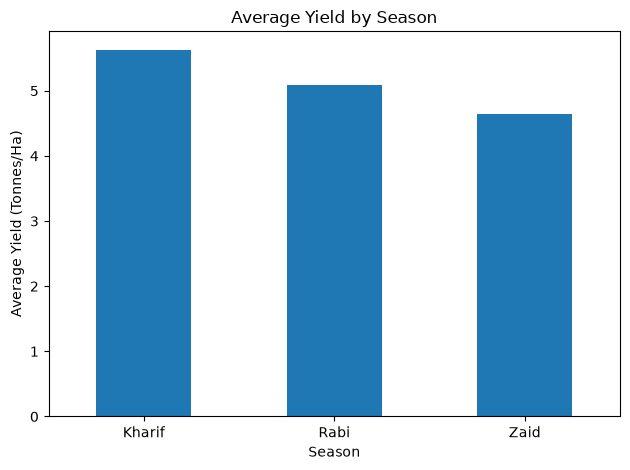

In [42]:
season_yield_mean = cleaned_df.groupby('Season')['Yield_Tonnes_Ha'].mean()

season_yield_mean.plot(kind='bar')

plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

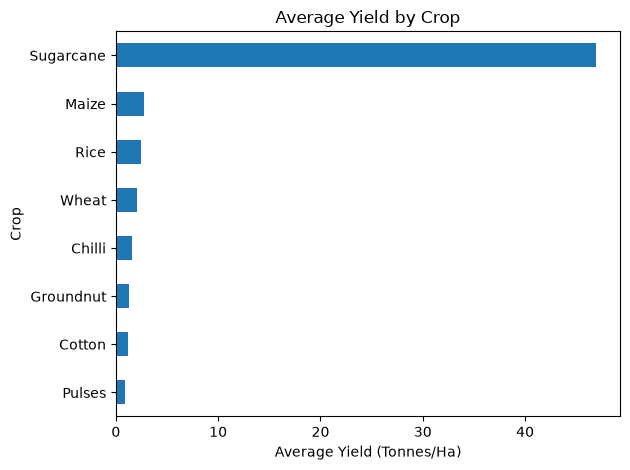

In [43]:
crop_yield = cleaned_df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values()

crop_yield.plot(kind='barh')

plt.title('Average Yield by Crop')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

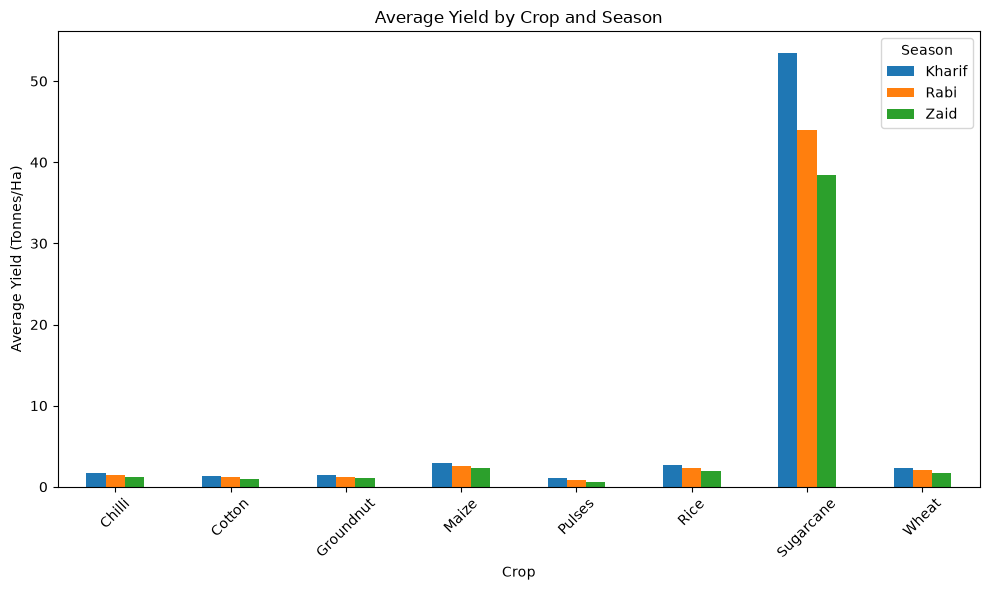

In [44]:
yield_pivot.plot(kind='bar', figsize=(10, 6))

plt.title('Average Yield by Crop and Season')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

## 7. Financial Performance Analysis

This section compares revenue, cost, profit, and profit margin across seasons and crop-season combinations. Profit margin here is calculated as (average profit / average revenue) × 100 for each group, not just the average profit value by itself.


In [45]:
season_profit = cleaned_df.groupby('Season')['Profit_INR'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

season_profit

,count,mean,median,min,max
Season,,,,,
Kharif,1779,178914.65,38808.0,-976860,4345421
Rabi,1627,87689.47,-3187.0,-1019223,3378879
Zaid,594,-24804.82,-62144.0,-965197,2349990


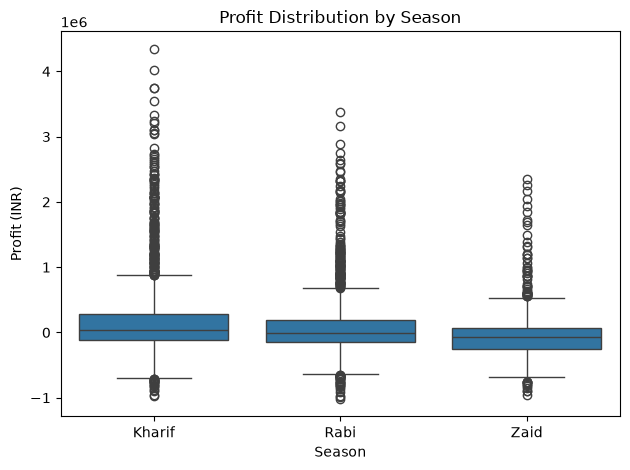

In [46]:
sns.boxplot(
    data=cleaned_df,
    x='Season',
    y='Profit_INR'
)

plt.title('Profit Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')
plt.tight_layout()
plt.show()

In [47]:
crop_season_profit = cleaned_df.groupby(
    ['Crop', 'Season']
)['Profit_INR'].agg(
    ['count', 'mean', 'median']
).round(2)

crop_season_profit

count        mean    median
Crop      Season                             
Chilli    Kharif    185   954380.42  705116.0
          Rabi      163   638572.50  470004.0
          Zaid       64   448659.09  350401.0
Cotton    Kharif    215   216999.55  136193.0
          Rabi      201   107343.59   50603.0
          Zaid       92   -53925.34  -11434.5
Groundnut Kharif    193   108265.44   87406.0
          Rabi      177    10416.54   24517.0
          Zaid       54   -68872.50  -38896.5
Maize     Kharif    234   -39332.67   -9883.5
          Rabi      233   -89133.40  -45813.0
          Zaid       84  -194049.17 -147455.5
Pulses    Kharif    221    43338.90   57156.0
          Rabi      213   -14309.14  -11734.0
          Zaid       62  -139227.81 -128893.0
Rice      Kharif    314   -64903.40  -39903.5
          Rabi      274   -98427.87  -49931.5
          Zaid      102  -227239.34 -183631.5
Sugarcane Kharif    125  1000790.81  940895.0
          Rabi      129   731612.86  622229.0
          Zaid       51   583635.80  556627.0
Wheat     Kharif    292  -105871.87  -57248.5
          Rabi      237  -119954.57  -76084.0
          Zaid       85  -193208.95 -125778.0

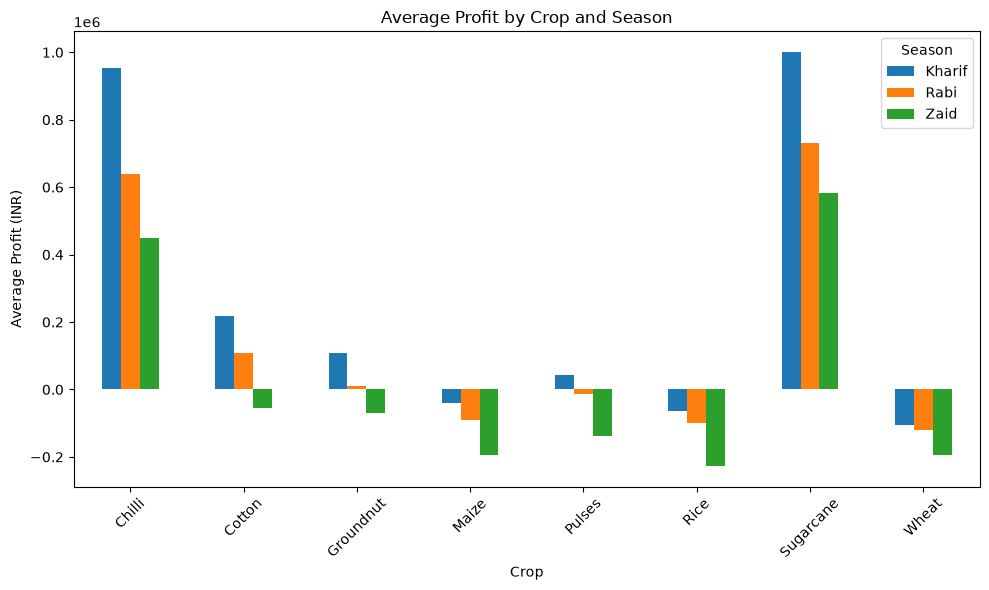

In [48]:
profit_pivot = cleaned_df.pivot_table(
    index='Crop',
    columns='Season',
    values='Profit_INR',
    aggfunc='mean'
)

profit_pivot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Average Profit by Crop and Season')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

In [49]:
season_financials = cleaned_df.groupby('Season')[
    ['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
].mean().round(2)

season_financials

,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,710719.06,531804.41,178914.65
Rabi,601526.05,513836.58,87689.47
Zaid,519171.90,543976.73,-24804.82


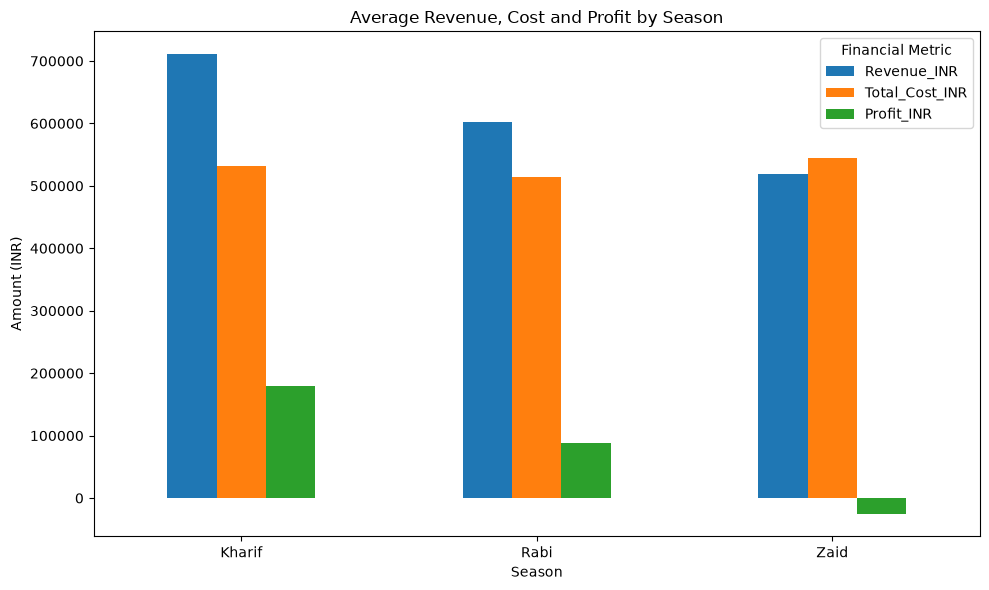

In [50]:
season_financials.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Average Revenue, Cost and Profit by Season')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=0)
plt.legend(title='Financial Metric')
plt.tight_layout()
plt.show()

In [51]:
season_margin = cleaned_df.groupby('Season').agg(
    Revenue_INR=('Revenue_INR', 'mean'),
    Profit_INR=('Profit_INR', 'mean')
)

season_margin['Profit_Margin_pct'] = (
    season_margin['Profit_INR'] /
    season_margin['Revenue_INR']
) * 100

season_margin.round(2)

,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,
Kharif,710719.06,178914.65,25.17
Rabi,601526.05,87689.47,14.58
Zaid,519171.90,-24804.82,-4.78


In [52]:
crop_season_margin = cleaned_df.groupby(
    ['Crop', 'Season']
).agg(
    Revenue_INR=('Revenue_INR', 'mean'),
    Profit_INR=('Profit_INR', 'mean')
)

crop_season_margin['Profit_Margin_pct'] = (
    crop_season_margin['Profit_INR'] /
    crop_season_margin['Revenue_INR']
) * 100

crop_season_margin.round(2)

Revenue_INR  Profit_INR  Profit_Margin_pct
Crop      Season                                            
Chilli    Kharif   1494091.73   954380.42              63.88
          Rabi     1140992.37   638572.50              55.97
          Zaid      994429.55   448659.09              45.12
Cotton    Kharif    713739.94   216999.55              30.40
          Rabi      637722.18   107343.59              16.83
          Zaid      469463.91   -53925.34             -11.49
Groundnut Kharif    594414.86   108265.44              18.21
          Rabi      505760.27    10416.54               2.06
          Zaid      480796.57   -68872.50             -14.32
Maize     Kharif    486047.01   -39332.67              -8.09
          Rabi      454728.04   -89133.40             -19.60
          Zaid      382831.30  -194049.17             -50.69
Pulses    Kharif    590276.29    43338.90               7.34
          Rabi      515813.30   -14309.14              -2.77
          Zaid      351609.31  -139227.81             -39.60
Rice      Kharif    491546.11   -64903.40             -13.20
          Rabi      379818.70   -98427.87             -25.91
          Zaid      332144.38  -227239.34             -68.42
Sugarcane Kharif   1561828.16  1000790.81              64.08
          Rabi     1269754.74   731612.86              57.62
          Zaid     1165236.35   583635.80              50.09
Wheat     Kharif    431595.94  -105871.87             -24.53
          Rabi      385277.84  -119954.57             -31.13
          Zaid      333265.15  -193208.95             -57.97

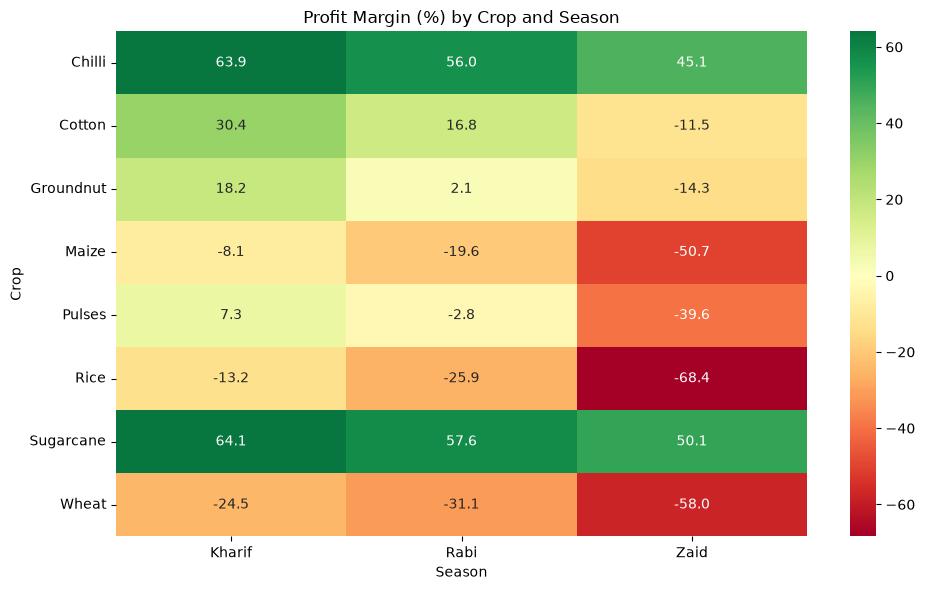

In [53]:
margin_pivot = crop_season_margin[
    'Profit_Margin_pct'
].unstack()

plt.figure(figsize=(10, 6))

sns.heatmap(
    margin_pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=0
)

plt.title('Profit Margin (%) by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

## 8. Water Usage and Efficiency Analysis

Here we look at how much water is used per season and how efficiently it's converted into production, followed by a comparison of the different irrigation methods.


In [54]:
season_water = cleaned_df.groupby('Season')['Water_Used_m3'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

season_water

,count,mean,median,min,max
Season,,,,,
Kharif,1779,6102.20,4469.0,139,36156
Rabi,1627,5846.99,4292.0,128,40902
Zaid,594,6419.89,4805.0,182,34392


In [55]:
season_water_efficiency = cleaned_df.groupby('Season')[
    'Water_Efficiency_t_per_1000m3'
].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(3)

season_water_efficiency

,count,mean,median,min,max
Season,,,,,
Kharif,1779,5.892,3.277,0.135,79.800
Rabi,1627,5.186,2.740,0.146,75.340
Zaid,594,4.413,2.302,0.140,48.545


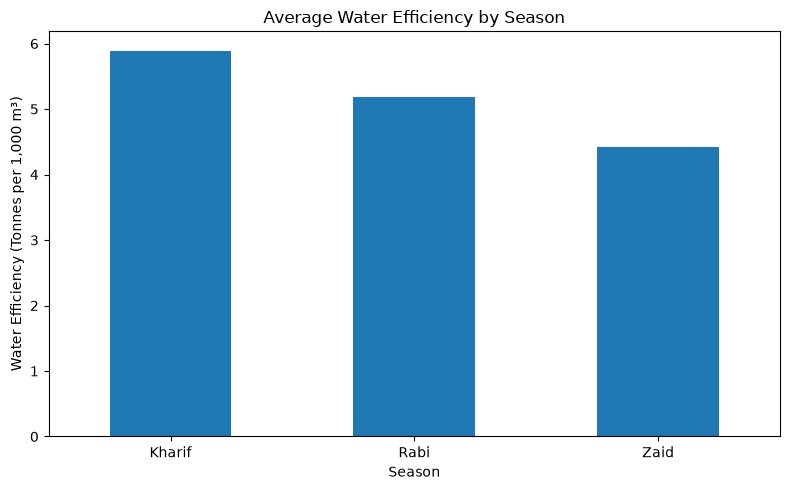

In [56]:
season_efficiency_mean = cleaned_df.groupby(
    'Season'
)['Water_Efficiency_t_per_1000m3'].mean()

season_efficiency_mean.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (Tonnes per 1,000 m³)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Farms,Avg_Yield,Avg_Water_Used,Avg_Water_Efficiency,Avg_Profit
Irrigation_Method,,,,,
Drip,915,6.67,5918.75,6.27,219626.00
Flood,1310,4.86,8026.47,3.44,73354.02
Rainfed,1041,4.60,3549.55,7.56,79050.37
Sprinkler,734,5.16,6208.26,4.67,91121.08


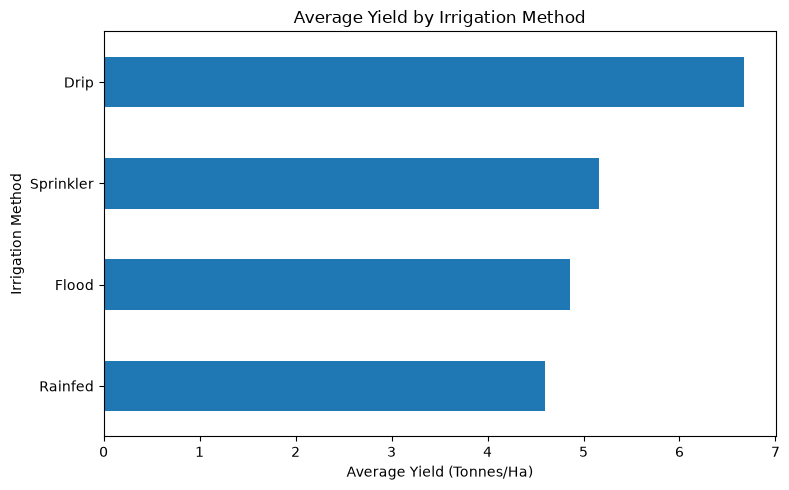

In [57]:
irrigation_analysis = cleaned_df.groupby('Irrigation_Method').agg(
    Farms=('Farm_ID', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Profit=('Profit_INR', 'mean')
).round(2)

display(irrigation_analysis)

irrigation_analysis['Avg_Yield'].sort_values().plot(
    kind='barh',
    figsize=(8, 5)
)

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Irrigation Method')
plt.tight_layout()
plt.show()

## 9. Environmental and Resource Analysis

Environmental factors (rainfall, temperature, etc.) and resource inputs (fertilizer, nitrogen, etc.) are compared against yield here, along with a summary of performance by state.


In [58]:
environment_cols = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha'
]

environment_correlation = cleaned_df[environment_cols].corr()['Yield_Tonnes_Ha']\
    .drop('Yield_Tonnes_Ha')\
    .sort_values(ascending=False)\
    .round(3)

environment_correlation

Rainfall_mm           0.027
Humidity_pct          0.011
Soil_Moisture_pct     0.010
Avg_Temperature_C     0.009
Sunlight_Hours_Day   -0.015
Soil_pH              -0.022
Name: Yield_Tonnes_Ha, dtype: float64

In [59]:
resource_cols = [
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha'
]

resource_correlation = cleaned_df[resource_cols].corr()['Yield_Tonnes_Ha']\
    .drop('Yield_Tonnes_Ha')\
    .sort_values(ascending=False)\
    .round(3)

resource_correlation

Nitrogen_kg_ha        0.054
Phosphorus_kg_ha      0.047
Potassium_kg_ha       0.005
Fertilizer_kg_ha     -0.000
Seed_Quality_Score   -0.008
Pesticide_Litre_ha   -0.009
Name: Yield_Tonnes_Ha, dtype: float64

### 9.1 State-Level Agricultural Performance

A quick summary of how farms, yield, and profit compare across the different states in the dataset.


In [60]:
state_analysis = cleaned_df.groupby('State').agg(
    Farms=('Farm_ID', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Pest_Risk=('Disease_Pest_Risk_pct', 'mean')
).round(2)

state_analysis.sort_values(
    'Avg_Profit',
    ascending=False
)

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency,Avg_Disease_Pest_Risk
State,,,,,
Punjab,484,6.12,136025.64,5.62,46.00
Maharashtra,512,5.02,135428.86,5.28,46.44
Karnataka,489,5.78,119422.34,5.56,46.06
Tamil Nadu,485,4.87,117744.75,5.31,46.28
Gujarat,488,5.75,117568.24,5.58,45.95
Telangana,516,5.05,108829.62,5.46,46.36
Madhya Pradesh,497,4.99,86840.76,5.27,47.08
Andhra Pradesh,529,4.63,73453.53,5.03,46.72


## 10. Statistical Analysis

The seasonal comparisons so far are based on averages, but averages alone don't tell us whether a difference is "real" or just due to random variation in the sample. To check this, non-parametric tests are used here (Kruskal-Wallis and Mann-Whitney U), since the data isn't normally distributed. Where multiple pairwise comparisons are made, a Bonferroni correction is applied to keep the results reliable.

Note: when a p-value is extremely small, Python can round it down to 0.0. In that case, the result is reported as **p < 0.001** instead of literally 0, since no p-value is ever truly exactly zero.


In [61]:
from scipy.stats import kruskal

# Seasonal groups
kharif = cleaned_df[cleaned_df['Season'] == 'Kharif']
rabi = cleaned_df[cleaned_df['Season'] == 'Rabi']
zaid = cleaned_df[cleaned_df['Season'] == 'Zaid']

# Kruskal-Wallis tests
yield_test = kruskal(
    kharif['Yield_Tonnes_Ha'],
    rabi['Yield_Tonnes_Ha'],
    zaid['Yield_Tonnes_Ha']
)

profit_test = kruskal(
    kharif['Profit_INR'],
    rabi['Profit_INR'],
    zaid['Profit_INR']
)

water_test = kruskal(
    kharif['Water_Efficiency_t_per_1000m3'],
    rabi['Water_Efficiency_t_per_1000m3'],
    zaid['Water_Efficiency_t_per_1000m3']
)

print("Yield — H-statistic:", round(yield_test.statistic, 3),
      "| p-value:", format_p(yield_test.pvalue))

print("Profit — H-statistic:", round(profit_test.statistic, 3),
      "| p-value:", format_p(profit_test.pvalue))

print("Water Efficiency — H-statistic:", round(water_test.statistic, 3),
      "| p-value:", format_p(water_test.pvalue))


Yield — H-statistic: 70.265 | p-value: < 0.001
Profit — H-statistic: 101.926 | p-value: < 0.001
Water Efficiency — H-statistic: 56.811 | p-value: < 0.001


In [62]:
from scipy.stats import mannwhitneyu
from itertools import combinations

seasons = ['Kharif', 'Rabi', 'Zaid']

variables = {
    'Yield': 'Yield_Tonnes_Ha',
    'Profit': 'Profit_INR',
    'Water Efficiency': 'Water_Efficiency_t_per_1000m3'
}

for variable_name, column in variables.items():
    print(f"\n{variable_name}")
    print("-" * 50)

    for s1, s2 in combinations(seasons, 2):
        group1 = cleaned_df[cleaned_df['Season'] == s1][column]
        group2 = cleaned_df[cleaned_df['Season'] == s2][column]

        test = mannwhitneyu(
            group1,
            group2,
            alternative='two-sided'
        )

        # Bonferroni correction: 3 pairwise comparisons per variable
        corrected_p = min(test.pvalue * 3, 1.0)

        print(
            f"{s1} vs {s2}: "
            f"U = {test.statistic:.1f}, "
            f"corrected p = {format_p(corrected_p)}"
        )



Yield
--------------------------------------------------
Kharif vs Rabi: U = 1593298.0, corrected p = < 0.001
Kharif vs Zaid: U = 643288.5, corrected p = < 0.001
Rabi vs Zaid: U = 541826.5, corrected p = < 0.001

Profit
--------------------------------------------------
Kharif vs Rabi: U = 1594632.5, corrected p = < 0.001
Kharif vs Zaid: U = 668508.0, corrected p = < 0.001
Rabi vs Zaid: U = 570725.0, corrected p = < 0.001

Water Efficiency
--------------------------------------------------
Kharif vs Rabi: U = 1559766.0, corrected p = < 0.001
Kharif vs Zaid: U = 634140.5, corrected p = < 0.001
Rabi vs Zaid: U = 545246.0, corrected p = < 0.001


## 11. Disease and Pest Risk Analysis

This looks at how disease/pest risk changes across seasons, since it can directly affect yield and profit.


In [63]:
disease_season = cleaned_df.groupby('Season')[
    'Disease_Pest_Risk_pct'
].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

disease_season

,count,mean,median,min,max
Season,,,,,
Kharif,1779,54.47,54.5,21.3,88.9
Rabi,1627,40.48,40.6,5.1,71.2
Zaid,594,38.22,37.9,5.0,71.6


## 12. Correlation Analysis

Spearman correlation is used here (instead of Pearson) since it doesn't assume the variables are normally distributed and can pick up on monotonic relationships even if they aren't perfectly linear.


In [64]:
from scipy.stats import spearmanr

risk_profit_corr, risk_profit_p = spearmanr(
    cleaned_df['Disease_Pest_Risk_pct'],
    cleaned_df['Profit_INR']
)

print("Spearman correlation:", round(risk_profit_corr, 3))
print("p-value:", format_p(risk_profit_p))


Spearman correlation: 0.097
p-value: < 0.001


The correlation is statistically significant (p < 0.001), which mainly reflects the large sample size (4,000 rows) — with that many observations, even small relationships tend to come out significant. But the correlation value itself, around **0.10**, is very weak. In practical terms, this means disease/pest risk and profit are not meaningfully related in this dataset — knowing one doesn't really tell you much about the other, even though the relationship is technically real and not due to chance.


## 13. Profitability Ranking

Crop-season combinations are ranked here by profit margin, to see which combinations are the most and least financially viable.


In [65]:
margin_ranking = crop_season_margin[
    ['Revenue_INR', 'Profit_INR', 'Profit_Margin_pct']
].sort_values(
    'Profit_Margin_pct',
    ascending=False
).round(2)

print("TOP 10 CROP-SEASON COMBINATIONS")
display(margin_ranking.head(10))

print("\nBOTTOM 10 CROP-SEASON COMBINATIONS")
display(margin_ranking.tail(10))

TOP 10 CROP-SEASON COMBINATIONS


,,Revenue_INR,Profit_INR,Profit_Margin_pct
Crop,Season,,,
Sugarcane,Kharif,1561828.16,1000790.81,64.08
Chilli,Kharif,1494091.73,954380.42,63.88
Sugarcane,Rabi,1269754.74,731612.86,57.62
Chilli,Rabi,1140992.37,638572.50,55.97
Sugarcane,Zaid,1165236.35,583635.80,50.09
Chilli,Zaid,994429.55,448659.09,45.12
Cotton,Kharif,713739.94,216999.55,30.40
Groundnut,Kharif,594414.86,108265.44,18.21
Cotton,Rabi,637722.18,107343.59,16.83



BOTTOM 10 CROP-SEASON COMBINATIONS


,,Revenue_INR,Profit_INR,Profit_Margin_pct
Crop,Season,,,
Rice,Kharif,491546.11,-64903.40,-13.20
Groundnut,Zaid,480796.57,-68872.50,-14.32
Maize,Rabi,454728.04,-89133.40,-19.60
Wheat,Kharif,431595.94,-105871.87,-24.53
Rice,Rabi,379818.70,-98427.87,-25.91
Wheat,Rabi,385277.84,-119954.57,-31.13
Pulses,Zaid,351609.31,-139227.81,-39.60
Maize,Zaid,382831.30,-194049.17,-50.69
Wheat,Zaid,333265.15,-193208.95,-57.97


## 14. Crop-Level Statistical Test

The same Kruskal-Wallis approach used for seasons is applied here to check whether yield differs significantly across the 8 crops in the dataset.


In [66]:
crop_groups = [
    cleaned_df[cleaned_df['Crop'] == crop]['Yield_Tonnes_Ha']
    for crop in cleaned_df['Crop'].unique()
]

crop_yield_test = kruskal(*crop_groups)

print("Kruskal-Wallis test for Yield across Crops")
print("H-statistic:", round(crop_yield_test.statistic, 3))
print("p-value:", format_p(crop_yield_test.pvalue))


Kruskal-Wallis test for Yield across Crops
H-statistic: 1875.657
p-value: < 0.001


## 15. Final Summary Tables

These tables pull together the season-level and crop-level numbers into one place, to make it easier to compare everything before summarizing the key findings.


In [67]:
final_season_summary = cleaned_df.groupby('Season').agg(
    Farms=('Farm_ID', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
)

# Profit margin has to be calculated from revenue and profit, not just copied from profit.
final_season_summary['Avg_Profit_Margin_pct'] = (
    final_season_summary['Avg_Profit'] / final_season_summary['Avg_Revenue']
) * 100

final_season_summary.round(2)


,Farms,Avg_Yield,Avg_Revenue,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk,Avg_Profit_Margin_pct
Season,,,,,,,,
Kharif,1779,5.63,710719.06,178914.65,6102.20,5.89,54.47,25.17
Rabi,1627,5.09,601526.05,87689.47,5846.99,5.19,40.48,14.58
Zaid,594,4.64,519171.90,-24804.82,6419.89,4.41,38.22,-4.78


In [68]:
key_variables = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Fertilizer_kg_ha',
    'Seed_Quality_Score',
    'Water_Used_m3',
    'Disease_Pest_Risk_pct',
    'Yield_Tonnes_Ha',
    'Profit_INR'
]

key_correlation = cleaned_df[key_variables].corr().round(2)

key_correlation

,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Nitrogen_kg_ha,Fertilizer_kg_ha,Seed_Quality_Score,Water_Used_m3,Disease_Pest_Risk_pct,Yield_Tonnes_Ha,Profit_INR
Rainfall_mm,1.00,0.20,0.52,0.01,0.02,-0.02,0.00,0.62,0.03,0.11
Avg_Temperature_C,0.20,1.00,0.08,0.02,0.02,-0.03,0.02,0.25,0.01,0.01
Soil_Moisture_pct,0.52,0.08,1.00,0.01,0.01,-0.02,0.00,0.38,0.01,0.09
Nitrogen_kg_ha,0.01,0.02,0.01,1.00,-0.03,0.01,0.02,-0.01,0.05,0.09
Fertilizer_kg_ha,0.02,0.02,0.01,-0.03,1.00,0.02,0.00,0.02,-0.00,-0.07
Seed_Quality_Score,-0.02,-0.03,-0.02,0.01,0.02,1.00,0.02,-0.02,-0.01,0.01
Water_Used_m3,0.00,0.02,0.00,0.02,0.00,0.02,1.00,0.01,0.39,0.19
Disease_Pest_Risk_pct,0.62,0.25,0.38,-0.01,0.02,-0.02,0.01,1.00,0.01,0.07
Yield_Tonnes_Ha,0.03,0.01,0.01,0.05,-0.00,-0.01,0.39,0.01,1.00,0.49
Profit_INR,0.11,0.01,0.09,0.09,-0.07,0.01,0.19,0.07,0.49,1.00


In [69]:
final_crop_summary = cleaned_df.groupby('Crop').agg(
    Farms=('Farm_ID', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
).sort_values(
    'Avg_Profit',
    ascending=False
).round(2)

final_crop_summary

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency,Avg_Disease_Risk
Crop,,,,,
Sugarcane,305,46.93,817187.99,30.48,45.40
Chilli,412,1.54,750878.34,2.95,46.06
Cotton,508,1.23,124546.92,1.94,45.97
Groundnut,424,1.32,44858.12,3.15,46.29
Pulses,496,0.92,-4238.05,2.90,46.57
Maize,551,2.72,-83978.33,5.60,45.54
Rice,690,2.44,-102213.50,1.95,46.50
Wheat,614,2.11,-123398.34,4.63,47.85


## 16. Key Findings

The code below pulls together the main results from the sections above into a short summary.


In [70]:
print("FINAL KEY FINDINGS")
print("=" * 60)

best_season_profit = cleaned_df.groupby('Season')['Profit_INR'].mean().idxmax()
worst_season_profit = cleaned_df.groupby('Season')['Profit_INR'].mean().idxmin()

best_crop_profit = cleaned_df.groupby('Crop')['Profit_INR'].mean().idxmax()
worst_crop_profit = cleaned_df.groupby('Crop')['Profit_INR'].mean().idxmin()

best_water_efficiency = cleaned_df.groupby('Season')[
    'Water_Efficiency_t_per_1000m3'
].mean().idxmax()

worst_water_efficiency = cleaned_df.groupby('Season')[
    'Water_Efficiency_t_per_1000m3'
].mean().idxmin()

highest_disease_risk = cleaned_df.groupby('Season')[
    'Disease_Pest_Risk_pct'
].mean().idxmax()

lowest_disease_risk = cleaned_df.groupby('Season')[
    'Disease_Pest_Risk_pct'
].mean().idxmin()

print("Best season by average profit:", best_season_profit)
print("Worst season by average profit:", worst_season_profit)
print("Best crop by average profit:", best_crop_profit)
print("Worst crop by average profit:", worst_crop_profit)
print("Best season by water efficiency:", best_water_efficiency)
print("Lowest season by water efficiency:", worst_water_efficiency)
print("Highest disease/pest risk season:", highest_disease_risk)
print("Lowest disease/pest risk season:", lowest_disease_risk)

FINAL KEY FINDINGS
Best season by average profit: Kharif
Worst season by average profit: Zaid
Best crop by average profit: Sugarcane
Worst crop by average profit: Wheat
Best season by water efficiency: Kharif
Lowest season by water efficiency: Zaid
Highest disease/pest risk season: Kharif
Lowest disease/pest risk season: Zaid


### 16.1 Notable Patterns

A few things stood out while going through the crop-season numbers more closely:

- Overall seasonal performance is not the same for every crop. Some crops that do reasonably well in Kharif turn unprofitable in Zaid, and a few (Rice, Wheat, Maize) actually run negative profit margins in most seasons, not just Zaid — Zaid just makes it worse.
- Sugarcane and Chilli are the exception: both stay clearly profitable across Kharif, Rabi, and Zaid, with margins consistently in the 45–65% range. Most other crops swing much more with the season.
- Yield also varies quite a bit by irrigation method, with Drip irrigation showing the highest average yield and Rainfed the lowest, which lines up with the general expectation that more controlled watering helps yield.


## 17. Final Data Quality Validation

Before wrapping up, the same checks used during cleaning are re-run one more time on the final dataset, just to confirm nothing broke during the analysis.


In [71]:
print("FINAL DATA QUALITY CHECK")
print("=" * 60)

print("Rows:", cleaned_df.shape[0])
print("Columns:", cleaned_df.shape[1])
print("Missing values:", cleaned_df.isnull().sum().sum())
print("Duplicate rows:", cleaned_df.duplicated().sum())

print("\nColumn data types:")
print(cleaned_df.dtypes.value_counts())

print("\nValidation checks:")

profit_check = (
    cleaned_df['Profit_INR'] ==
    cleaned_df['Revenue_INR'] - cleaned_df['Total_Cost_INR']
).all()

production_difference = (
    cleaned_df['Production_Tonnes'] -
    cleaned_df['Farm_Area_Hectares'] * cleaned_df['Yield_Tonnes_Ha']
).abs().max()

revenue_difference = (
    cleaned_df['Revenue_INR'] -
    cleaned_df['Production_Tonnes'] * cleaned_df['Market_Price_INR_Tonne']
).abs().max()

efficiency_difference = (
    cleaned_df['Water_Efficiency_t_per_1000m3'] -
    (cleaned_df['Production_Tonnes'] /
     cleaned_df['Water_Used_m3'] * 1000)
).abs().max()

print("Profit calculation valid:", profit_check)
print("Maximum production calculation difference:", round(production_difference, 4))
print("Maximum revenue calculation difference:", round(revenue_difference, 4))
print("Maximum water efficiency difference:", round(efficiency_difference, 4))

FINAL DATA QUALITY CHECK
Rows: 4000
Columns: 29
Missing values: 0
Duplicate rows: 0

Column data types:
float64    17
str         6
int64       5
bool        1
Name: count, dtype: int64

Validation checks:
Profit calculation valid: True
Maximum production calculation difference: 90.9116
Maximum revenue calculation difference: 0.5
Maximum water efficiency difference: 0.0005


In [72]:
production_check = cleaned_df[
    (
        cleaned_df['Production_Tonnes'] -
        cleaned_df['Farm_Area_Hectares'] * cleaned_df['Yield_Tonnes_Ha']
    ).abs() > 0.01
]

print("Rows with production mismatch:", len(production_check))

display(
    production_check[
        [
            'Farm_ID',
            'Crop',
            'Season',
            'Farm_Area_Hectares',
            'Yield_Tonnes_Ha',
            'Production_Tonnes'
        ]
    ].head(20)
)

Rows with production mismatch: 32


,Farm_ID,Crop,Season,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes
55,SF10056,Groundnut,Rabi,11.70,1.290,19.42
163,SF10164,Pulses,Zaid,3.55,0.660,1.06
555,SF10556,Chilli,Rabi,7.94,1.560,15.64
648,SF10649,Groundnut,Rabi,6.14,1.290,8.66
650,SF10651,Maize,Rabi,13.23,2.815,11.77
777,SF10778,Cotton,Rabi,1.83,1.200,2.42
874,SF10875,Rice,Kharif,3.15,2.880,3.87
899,SF10900,Pulses,Rabi,6.65,0.900,6.38
1133,SF11134,Cotton,Kharif,10.89,1.445,15.46
1251,SF11252,Chilli,Zaid,9.92,1.220,12.20


In [73]:
production_difference = (
    cleaned_df['Production_Tonnes'] -
    cleaned_df['Farm_Area_Hectares'] * cleaned_df['Yield_Tonnes_Ha']
).abs()

print("Rows with production mismatch > 0.01:", (production_difference > 0.01).sum())
print("Rows with production mismatch <= 0.01:", (production_difference <= 0.01).sum())

print("\nMaximum difference among rows with difference <= 0.01:")
print(round(production_difference[production_difference <= 0.01].max(), 4))


Rows with production mismatch > 0.01: 32
Rows with production mismatch <= 0.01: 3968

Maximum difference among rows with difference <= 0.01:
0.005


In [74]:
print("FINAL PROJECT VALIDATION")
print("=" * 60)

print("Rows:", cleaned_df.shape[0])
print("Columns:", cleaned_df.shape[1])
print("Missing values:", cleaned_df.isnull().sum().sum())
print("Duplicate rows:", cleaned_df.duplicated().sum())

print("\nOriginal financial validation:")
profit_check = (
    cleaned_df['Profit_INR'] ==
    cleaned_df['Revenue_INR'] - cleaned_df['Total_Cost_INR']
).all()

print("Profit = Revenue - Cost:", profit_check)

print("\nProduction validation:")
production_difference = (
    cleaned_df['Production_Tonnes'] -
    cleaned_df['Farm_Area_Hectares'] * cleaned_df['Yield_Tonnes_Ha']
).abs()

print("Rows consistent with cleaned yield:",
      (production_difference <= 0.01).sum())

print("Rows affected by yield imputation:",
      (production_difference > 0.01).sum())

# Cross-check: the mismatched rows should be exactly the rows we flagged earlier
flagged_count = cleaned_df['Yield_Imputed_Flag'].sum()
mismatched_count = (production_difference > 0.01).sum()
print("Rows flagged as yield-imputed:", flagged_count)
print("Flagged rows match mismatched rows:", flagged_count == mismatched_count)

print("Maximum difference among consistent rows:",
      round(production_difference[production_difference <= 0.01].max(), 4))

print("\nRevenue validation:")
revenue_difference = (
    cleaned_df['Revenue_INR'] -
    cleaned_df['Production_Tonnes'] *
    cleaned_df['Market_Price_INR_Tonne']
).abs()

print("Maximum revenue difference:",
      round(revenue_difference.max(), 4))

print("\nWater efficiency validation:")
efficiency_difference = (
    cleaned_df['Water_Efficiency_t_per_1000m3'] -
    (
        cleaned_df['Production_Tonnes'] /
        cleaned_df['Water_Used_m3'] * 1000
    )
).abs()

print("Maximum efficiency difference:",
      round(efficiency_difference.max(), 4))

print("\nFINAL STATUS: DATA READY FOR PROJECT DOCUMENTATION")


FINAL PROJECT VALIDATION
Rows: 4000
Columns: 29
Missing values: 0
Duplicate rows: 0

Original financial validation:
Profit = Revenue - Cost: True

Production validation:
Rows consistent with cleaned yield: 3968
Rows affected by yield imputation: 32
Rows flagged as yield-imputed: 32
Flagged rows match mismatched rows: True
Maximum difference among consistent rows: 0.005

Revenue validation:
Maximum revenue difference: 0.5

Water efficiency validation:
Maximum efficiency difference: 0.0005

FINAL STATUS: DATA READY FOR PROJECT DOCUMENTATION


## 18. Recommendations

Based on everything above, a few practical takeaways come out of this analysis:

- **Kharif is the season to prioritize.** It has the highest average profit and the best water efficiency of the three seasons, so it's the safest bet for most crops.
- **Sugarcane and Chilli are consistently strong performers.** Both stay profitable across all three seasons and are worth prioritizing where growing conditions allow.
- **Zaid needs more careful planning.** It has the lowest average profit and water efficiency, so cost and resource management matter more here than in the other seasons.
- **Some crop-season combinations are simply loss-making.** Rice, Wheat, and Maize show negative profit margins in most seasons, and especially in Zaid — these need to be reviewed rather than continued by default.
- **Irrigation method matters for yield.** Drip irrigation shows clearly higher average yield than Rainfed, so the choice of irrigation system is worth factoring into planning decisions.
- **Water usage and disease/pest risk should be tracked more closely**, since both directly affect the final profit outcome.
- **Crop and season choices should be based on more than yield alone** — profitability and water efficiency together give a more complete picture of what's actually working.


## 19. Conclusion

This analysis shows clear differences in agricultural performance across seasons and crops. Kharif comes out ahead on both profit and water efficiency, while Zaid is the weakest on both counts. At the crop level, Sugarcane and Chilli are the standout performers, staying profitable in every season, while Rice, Wheat, and Maize struggle with negative margins in most seasons.

The statistical tests confirm that these differences in yield, profit, and water efficiency across seasons are not just due to chance — they are statistically significant. Yield also differs significantly across crops. That said, not every significant result is a strong one: the relationship between disease/pest risk and profit, while statistically significant, is weak in practical terms and shouldn't be over-interpreted.

Overall, the results support planning by season and by crop rather than treating all farming activity the same way. Kharif and high-margin crops like Sugarcane and Chilli deserve more attention and investment, while Zaid and consistently loss-making crop-season combinations need closer cost management or reconsideration altogether.
